<h1 style="color: #f686bd">Aprendizado Não Supervisionado Prático com Scikit-Learn</h1>

Neste notebook, vamos aplicar os conceitos de **Redução de Dimensionalidade (PCA)** e **Clusterização (K-Means)**. 

Diferente do aprendizado supervisionado, aqui **nós não temos um gabarito** (uma resposta certa como 'Nota' ou 'Aprovado'). Nosso objetivo é entregar os dados puros para o algoritmo e pedir para ele encontrar **padrões ocultos** e **agrupar os alunos similares** automaticamente.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ferramentas do Scikit-Learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

<h3 style="color: #f686bd">1. Carregando e Preparando os Dados (Pré-Processamento)</h3>
Assim como no notebook passado, precisamos transformar os textos em números. E para não enviesar o modelo (fingir que estamos tentando prever notas), vamos **remover a coluna `Nota_na_Prova` completamente da nossa análise**, focando apenas no PERFIL do aluno.

In [2]:
# Carregando os dados
df = pd.read_csv('data/02_dados.csv')

# Removendo a nota para o modelo não "colar", nosso foco é apenas o perfil/comportamento do aluno
df_perfil = df.drop(columns=['Nota_na_Prova'])

# Convertendo texto para números
colunas_texto = df_perfil.select_dtypes(include=['object']).columns
encoder = LabelEncoder()
for col in colunas_texto:
    df_perfil[col] = encoder.fit_transform(df_perfil[col])
    
display(df_perfil.head(3))

,Horas_de_Estudo,Frequência,Envolvimento_dos_Pais,Acesso_a_Recursos,Atividades_Extracurriculares,Horas_de_Sono,Notas_Anteriores,Nível_de_Motivação,Acesso_à_Internet,Aulas_de_Reforço,Renda_Familiar,Qualidade_dos_Professores,Tipo_de_Escola,Influência_dos_Colegas,Atividade_Física,Dificuldades_de_Aprendizagem,Nível_de_Escolaridade_dos_Pais,Distância_de_Casa,Sexo
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1


<h4 style="color: #f686bd">A importância do Escalonamento (Standardization)</h4>

No aprendizado *não supervisionado*, algoritmos como PCA e K-Means dependem do cálculo de **distância física** entre os pontos num gráfico. 
Se você tem variáveis em escalas muito diferentes (ex: `Horas_de_Sono` vai de 0 a 10, e `Frequência` vai de 0 a 100), o modelo vai achar que a Frequência é muito mais importante só porque seu número absoluto é maior.
Para resolver isso, usamos o **StandardScaler**, que nivela todas as colunas para o mesmo peso (mesma escala).

In [3]:
scaler = StandardScaler()
df_escalonado = scaler.fit_transform(df_perfil)

# O resultado do escaleamento é uma matriz (Array NumPy). 
# Cada coluna agora tem uma média em 0 e um desvio padrão de 1.
print("Tamanho dos dados:", df_escalonado.shape)
print("Exemplo da 1ª linha escalonada:")
print(np.round(df_escalonado[0], 2))

Tamanho dos dados: (2000, 19)
Exemplo da 1ª linha escalonada:
[ 0.46  0.37 -0.29 -1.39 -1.21  0.   -0.16 -0.37  0.28 -1.23 -0.31  0.72
  0.64  1.07 -0.01 -0.36  0.09  0.75  0.84]


<h3 style="color: #f686bd">2. Redução de Dimensionalidade (PCA)</h3>
Temos **19 características** (colunas) para cada aluno. É humanamente impossível desenhar um gráfico em 19 dimensões para vermos como esses dados se espalham espacialmente.

Vamos usar a **Análise de Componentes Principais (PCA)** para comprimir essas 19 colunas (preservando o máximo possível de informação) em apenas **2 Componentes Principais (eixos x e y)** para desenharmos um gráfico 2D.

In [4]:
# Criar as duas componentes X e Y
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_escalonado)

# Guardando o resultado em um DataFrame mais limpo para gerarmos os gráficos depois
df_pca = pd.DataFrame(data=componentes, columns=['Componente_1_X', 'Componente_2_Y'])
display(df_pca.head())

# Quanto da informação original essas 2 novas colunas conseguiram preservar?
informacao_preservada = pca.explained_variance_ratio_.sum() * 100
print(f"Nossa compressão conseguiu preservar {informacao_preservada:.1f}% da informação (variância) de todas as 19 variáveis originais!")

,Componente_1_X,Componente_2_Y
0,-0.300300,0.331919
1,1.884921,-0.052037
2,-0.112155,-1.148968
3,0.452287,0.107102
4,0.832208,-1.358333


Nossa compressão conseguiu preservar 12.2% da informação (variância) de todas as 19 variáveis originais!


<hr>
<h3 style="color: #f686bd">3. Agrupamento / Clusterização (K-Means)</h3>
Agora que temos o nosso `X` e `Y` do PCA, vamos pedir para o **K-Means** tentar encontrar automaticamente **4 grupos de perfis de estudantes similares** (clusters) na nossa base.

*(Obs: estamos usando os dados com 19 variáveis originais escalonadas para o K-Means rodar, e depois usamos o PCA com 2 componentes só para desenhar e pintar de acordo com os resultados do K-Means!)*

In [5]:
# Rodando o modelo pedindo 4 Perfis/Grupos diferentes
kmeans = KMeans(n_clusters=4, random_state=42)

# Treinando e já pegando os RÓTULOS (clusters) descobertos (de 0 a 3)
clusters_descobertos = kmeans.fit_predict(df_escalonado)

print("Exemplo dos primeiros 15 alunos processados e em quais grupos eles caíram:")
print(clusters_descobertos[:15])

Exemplo dos primeiros 15 alunos processados e em quais grupos eles caíram:
[1 3 1 0 1 1 2 0 2 1 2 2 3 2 2]


Vamos colocar esses `clusters_descobertos` (nossa cor do grupo) dentro do nosso mini dataframe de 2 Componentes (X e Y) e criar o **Gráfico de Dispersão K-Means + PCA:**

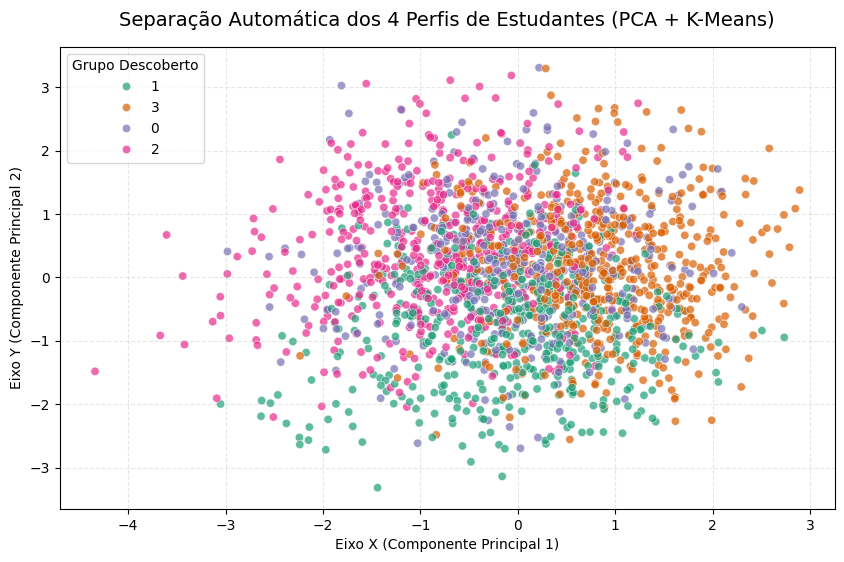

In [6]:
# Injetando os rótulos descobertos no nosso DataFrame do gráfico (para usarmos de cor)
df_pca['Cluster'] = clusters_descobertos

# Formatando a coluna Cluster como texto/categoria para ficar bonito no gráfico do seaborn
df_pca['Cluster'] = df_pca['Cluster'].astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Componente_1_X', y='Componente_2_Y', hue='Cluster', 
                palette='Dark2', data=df_pca, alpha=0.7)

plt.title('Separação Automática dos 4 Perfis de Estudantes (PCA + K-Means)', fontsize=14, pad=15)
plt.xlabel('Eixo X (Componente Principal 1)')
plt.ylabel('Eixo Y (Componente Principal 2)')
plt.legend(title='Grupo Descoberto')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

✅ **O que acabamos de fazer?** 
Mostramos um exemplo completo de Aprendizado Não Supervisionado! O modelo engoliu a base, nós encolhemos ela para 2 eixos só para poder desenhar (PCA) e a máquina dividiu todos os registros em 4 grupos organizados (K-Means), definindo *matematicamente* quais alunos têm comportamentos similares.